# Analysis results across session

In [1]:
import os
import numpy as np
import mat73
import pandas as pd
import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import h5py

import pyNeuroDAP as ndap

/Users/shunli/miniconda3/envs/pyNeuroDAP/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Setup

In [2]:
# all_sessions = [
#     '20251202-SL412-Random1_g0',
# #     '20251203-SL412-Random2_g0',
# #     '20251205-SL412-Random3_g0',
# #     '20251206-SL412-Random4_g0',
# #     '20251207-SL412-Reward1_g0',
# #     '20251208-SL412-Reward2_g0',
# #     '20251209-SL412-Reward3_g0',
# #     '20251210-SL412-Reward4_g0',
# #     '20251211-SL412-Punish1_g0',
# #     '20251212-SL412-Punish2_g0',
# #     '20251213-SL412-Punish3_g0',
# #     '20251214-SL412-Punish4_g0',
# #     '20251215-SL412-Reward5_g0',
# #     '20251216-SL412-Punish5_g0',
# #     '20251217-SL412-Reward6_g0',
# #     '20251218-SL412-Punish6_g0',
# ]

session_name = '20251202-SL412-Random1_g0'

# Read data
exp_name = '202512-Ephys-LHb'
session_path = rf'/Users/shunli/Projects/pyNeuroDAP/Data/{session_name}'
spike_path = os.path.join(session_path, rf'AIND_{session_name}')
nwb_path = os.path.join(session_path, 'nwb','ecephys_session_block0_recording1.nwb')
save_folder = os.path.join(session_path, 'results')

print('Analyzing session: ', session_name)
print('Session path: ', session_path)
print('Spike path: ', spike_path)
print('Save folder: ', save_folder)

Analyzing session:  20251202-SL412-Random1_g0
Session path:  /Users/shunli/Projects/pyNeuroDAP/Data/20251202-SL412-Random1_g0
Spike path:  /Users/shunli/Projects/pyNeuroDAP/Data/20251202-SL412-Random1_g0/AIND_20251202-SL412-Random1_g0
Save folder:  /Users/shunli/Projects/pyNeuroDAP/Data/20251202-SL412-Random1_g0/results


In [3]:
# h5_path = save_folder + f'/analysis-{session_name}.h5'
# session_data = ndap.load_session_data(h5_path, lazy=False, verbose=False)

### Plot units on NP2 channel map

Parse the session `.imro` file, map each AP channel index to probe (x, y), then overlay selected `unit_ids` using their `peak_channel` from `cluster_info`.

In [4]:
# Create channel map
import re

# --- Parse IMRO file to build NP2 channel map ---
imro_path = '/Users/shunli/Projects/pyNeuroDAP/Data/NP2-LHb-3500.imro'
with open(imro_path) as f:
    imro_raw = f.read().strip()

# NP2 multishank (type 2013): each entry is (chan_id shank_id bank ref_id electrode_id)
entries = re.findall(r'\((\d+)\s+(\d+)\s+(\d+)\s+(\d+)\s+(\d+)\)', imro_raw)

NP2_SHANK_PITCH = 250  # um between shanks
NP2_COL_PITCH = 32     # um between columns within a shank
NP2_ROW_PITCH = 15     # um between rows

channel_map = []
for chan_id, shank_id, bank, ref_id, elec_id in entries:
    chan_id, shank_id, elec_id = int(chan_id), int(shank_id), int(elec_id)
    col = elec_id % 2
    row = elec_id // 2
    x = shank_id * NP2_SHANK_PITCH + col * NP2_COL_PITCH
    y = row * NP2_ROW_PITCH
    channel_map.append({'channel_id': chan_id, 'shank_id': shank_id,
                        'electrode_id': elec_id, 'x': x, 'y': y})

channel_df = pd.DataFrame(channel_map)

In [5]:
import ast
import re
import pandas as pd

optotag_path = r'/Users/shunli/Projects/pyNeuroDAP/Results/SL412/optotag_results_all_sessions.txt'

# ---------------------------
# Choose what to load:
#   - session_selector = session_name   -> one specific session
#   - session_selector = "all"          -> all sessions
#   - session_selector = None           -> all sessions
# ---------------------------
# session_selector = session_name
session_selector = "all"

with open(optotag_path, 'r') as f:
    txt = f.read()

# Parse every session block in the file
pattern = re.compile(
    r"Session:\s*(?P<session>.+?)\s*[\r\n]+"
    r"[\s\S]*?Tagged units\s*\(unit_ids\)\s*:\s*(?P<tagged>\[[^\]]*\])"
    r"[\s\S]*?Peak channels\s*:\s*(?P<peaks>\[[^\]]*\])",
    re.MULTILINE
)

rows = []

for m in pattern.finditer(txt):
    session = m.group("session").strip()
    tagged_units = ast.literal_eval(m.group("tagged"))
    peak_channels = ast.literal_eval(m.group("peaks"))

    if len(tagged_units) != len(peak_channels):
        raise ValueError(
            f"Tagged units and peak channels length mismatch for {session}: "
            f"{len(tagged_units)} vs {len(peak_channels)}"
        )

    # Keep only the requested session unless using all sessions
    if session_selector not in [None, "all"] and session != session_selector:
        continue

    for unit_id, peak_channel in zip(tagged_units, peak_channels):
        rows.append({
            "session": session,
            "unit_ids": unit_id,
            "peak_channel": peak_channel
        })

if not rows:
    if session_selector in [None, "all"]:
        raise ValueError(f"No sessions found in {optotag_path}")
    else:
        raise ValueError(f"Could not find session '{session_selector}' in {optotag_path}")

unit_peak = pd.DataFrame(rows)
unit_peak = unit_peak.merge(
    channel_df,
    left_on='peak_channel',
    right_on='channel_id',
    how='left'
)

# Optional:
# # If you selected a single session and don't want the session column:
# if session_selector not in [None, "all"]:
#     unit_peak = unit_peak.drop(columns=["session"])

# # --- Select units and find their peak channels ---
# selected_units = [4, 203, 302]
# unit_peak = cluster_info[cluster_info['unit_ids'].isin(selected_units)][['unit_ids', 'peak_channel']].copy()
# unit_peak = unit_peak.merge(channel_df, left_on='peak_channel', right_on='channel_id', how='left')

# unit_peak

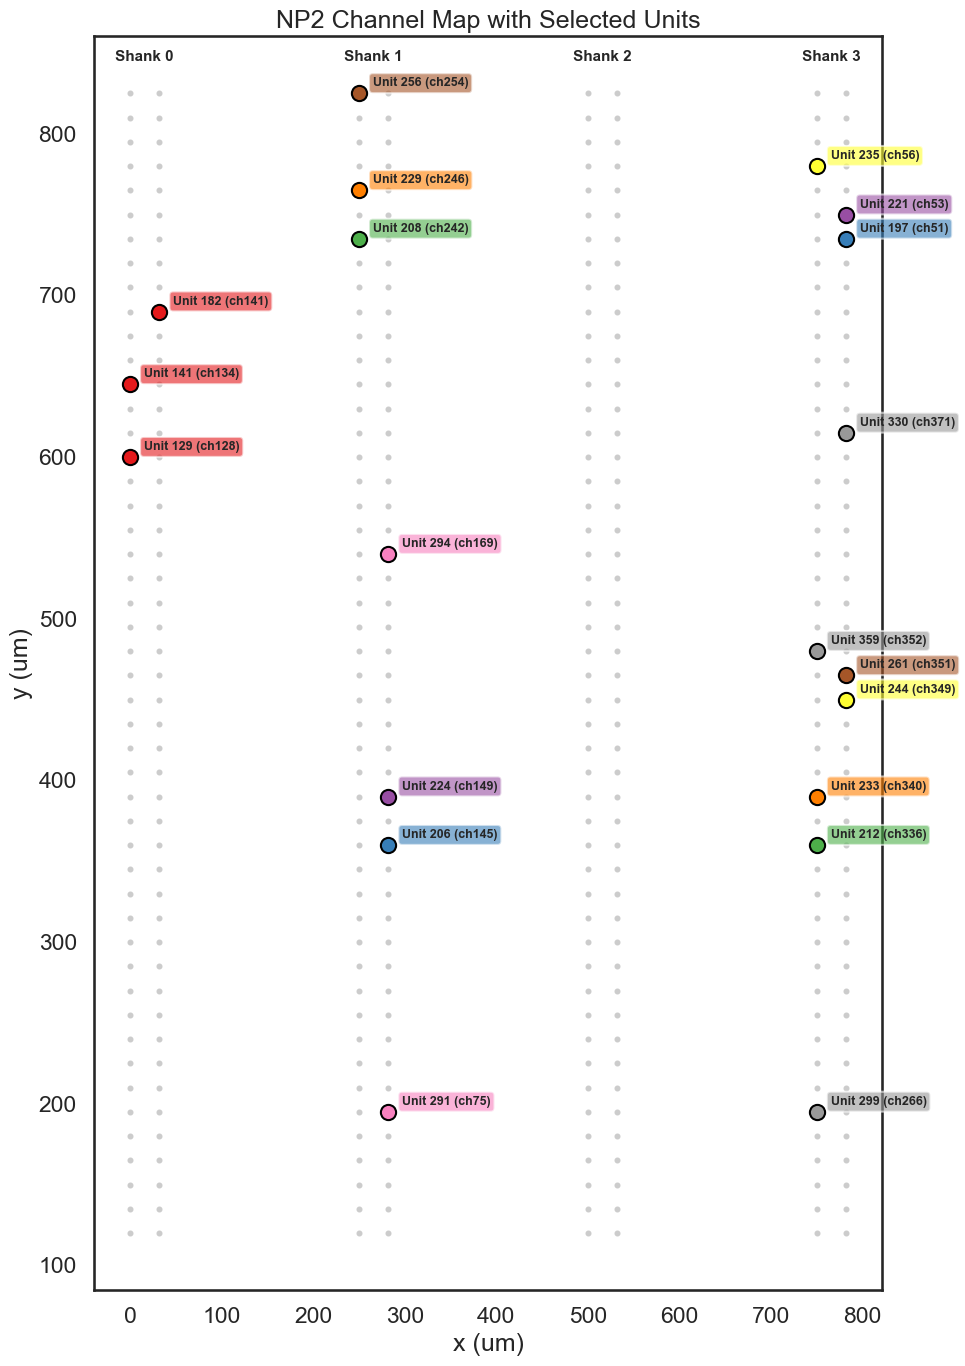

In [6]:
# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 14))

for shank_id, grp in channel_df.groupby('shank_id'):
    ax.scatter(grp['x'], grp['y'], s=8, c='#ccc', zorder=1)

cmap = plt.cm.Set1
for i, (_, row) in enumerate(unit_peak.iterrows()):
    color = cmap(i / max(len(unit_peak) - 1, 1))
    ax.scatter(row['x'], row['y'], s=120, c=[color], edgecolors='k',
               linewidths=1.5, zorder=3)
    ax.annotate(f"Unit {int(row['unit_ids'])} (ch{int(row['peak_channel'])})",
                (row['x'], row['y']), fontsize=9, fontweight='bold',
                xytext=(10, 5), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', fc=color, alpha=0.6))

for sid in sorted(channel_df['shank_id'].unique()):
    cx = sid * NP2_SHANK_PITCH + NP2_COL_PITCH / 2
    ax.text(cx, channel_df['y'].max() + 20, f'Shank {sid}',
            ha='center', fontsize=11, fontweight='bold')

ax.set_xlabel('x (um)')
ax.set_ylabel('y (um)')
ax.set_title('NP2 Channel Map with Selected Units')
plt.tight_layout()
plt.show()

# print(unit_peak[['unit_ids', 'peak_channel', 'shank_id', 'electrode_id', 'x', 'y']])
# Save figure as pdf
results_folder = r'/Users/shunli/Projects/pyNeuroDAP/Results/SL412'
fig.savefig(os.path.join(results_folder, 'optotag_channel_map.pdf'), dpi=300)


### Plot PSTH near blue opto


In [7]:
# event = optotag_onsets
# # event = blueLaser_onsets[:50] # for reward1 and after
# # event = blueLaser_onsets[-50:] # for random4

# event_label = 'blue opto'
# bin_size_ms = 5             # in ms
# time_range = (-0.05,0.1)    # in sec
# event_color = 'tab:cyan'
# event_duration = 0.01        # in sec

# # Run salt to find optotagged units
# salt_results = ndap.run_salt(
#     spikes, event,
#     test_window=0.02,
#     bin_size=0.001,
#     baseline_duration=1.0,
#     same_system=False, params=params,
#     include_units=good_units,
#     unit_ids=good_unit_ids,
#     expected_direction='excite',
#     reliability_threshold=0.25,  # optional: fires on ≥25% of trials
# )
# tagged_units = salt_results['unit_ids'][salt_results['tagged']]
# print(f"Tagged units: {tagged_units}")

# # Print rows of optotagged units (show unit_ids, global_unit_ids, peak_channel, default_qc, manual_quality, quality)
# # cols_to_show = ['unit_ids', 'global_unit_ids', 'peak_channel', 'quality']
# # print(cluster_info_enhanced.loc[cluster_info_enhanced['unit_ids'].isin(tagged_units), cols_to_show])

# # Print the range of peak_channel for the optotagged units
# print(f"Peak channel range for optotagged units: {np.min(cluster_info_enhanced.loc[cluster_info_enhanced['unit_ids'].isin(tagged_units), 'peak_channel'])} to {np.max(cluster_info_enhanced.loc[cluster_info_enhanced['unit_ids'].isin(tagged_units), 'peak_channel'])}")

# # Plot PSTH of blue opto
# # ndap.plot_all_units(spikes, event, time_range, plot_style='raster', 
# #                     good_units=good_units, good_unit_ids=good_unit_ids,
# #                     same_system=False, params=params, bin_size_ms=bin_size_ms,
# #                     event_color=event_color, event_duration=event_duration, event_label=event_label,
# #                     save_figure=False, save_folder=save_folder)


### Plot PSTH of events

In [8]:
# # Plot PSTH aligned to water
# event = water_lick_onsets
# event_label = 'water'
# bin_size_ms = 5             # in ms
# time_range = (-0.5,2)       # in sec
# event_color = 'tab:cyan'
# event_duration = 0.2        # in sec

# ndap.plot_all_units(spikes, event, time_range, plot_style='raster', 
#                     good_units=good_units, good_unit_ids=good_unit_ids,
#                     same_system=False, params=params, bin_size_ms=bin_size_ms,
#                     event_color=event_color, event_duration=event_duration, event_label=event_label,
#                     save_figure=False, save_folder=save_folder)

### Plot response changes during event period across trials

In [11]:
# Load data from analysis file
h5_path = save_folder + f'/analysis-{session_name}.h5'
session_data = ndap.load_session_data(h5_path, groups='trials_spikes', verbose=True)

# session_data

Requested groups: {'s', 'k', 'e', 'l', 'a', 'i', '_', 'p', 'r', 't'}
Analysis data loaded for session: /Users/shunli/Projects/pyNeuroDAP/Data/20251202-SL412-Random1_g0/results/analysis-20251202-SL412-Random1_g0.h5


NameError: name 'good_unit_ids' is not defined

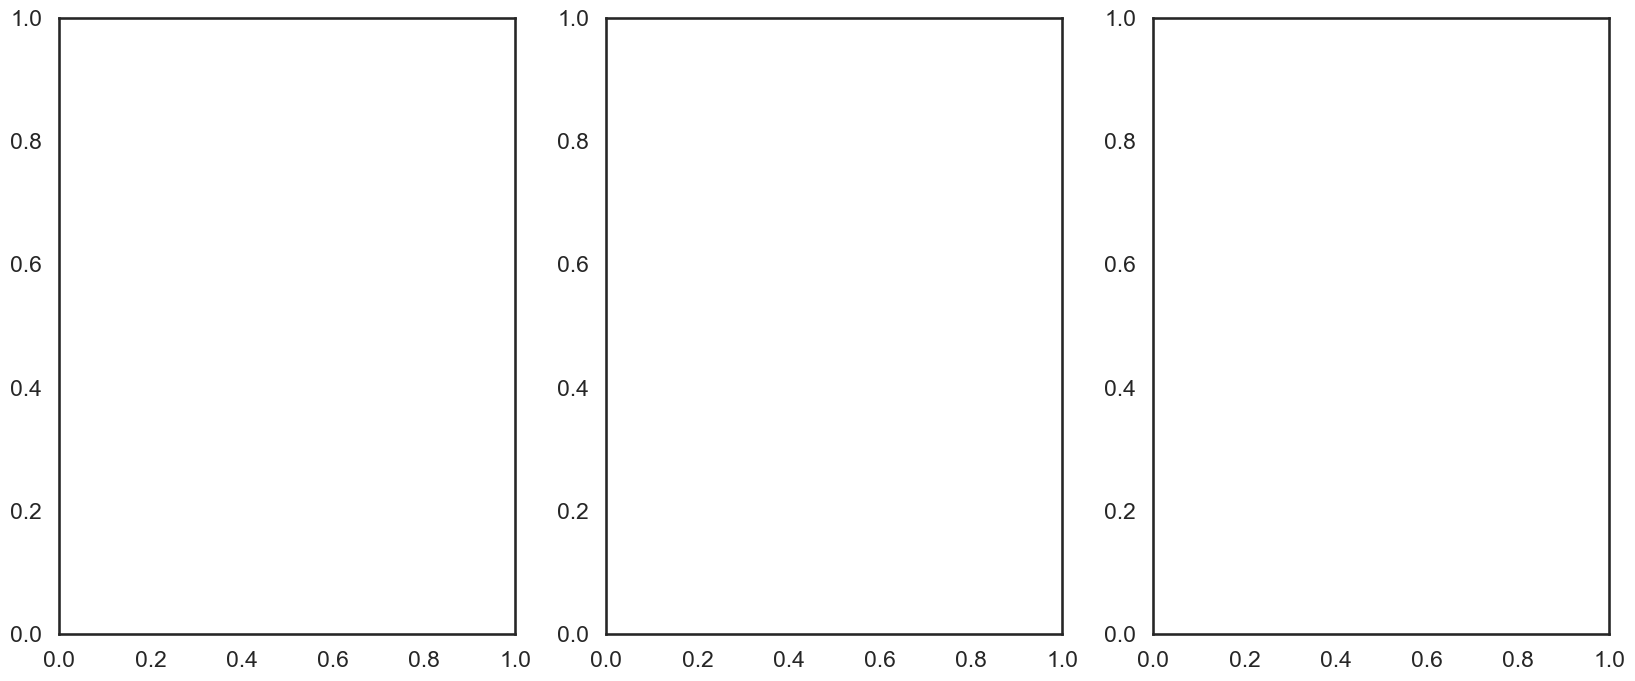

In [10]:
# Plot trial vs normalized spikes for each unit, with x-axis as individual trial
fig, axs = plt.subplots(1, 3, figsize=(20, 8))

# Plot grouped event rates (averaged every n_grouped_trials)
for i, unit_id in enumerate(good_unit_ids):
    axs[0].plot(
        np.arange(event_rates_diff_grouped.shape[1]) * n_grouped_trials,
        event_rates_diff_grouped[i],
        marker='o',
    )
axs[0].set_xlabel(f'Trial (grouped every {n_grouped_trials})')
axs[0].set_ylabel(r'$\Delta$ Firing rate (Hz)')
axs[0].set_title(f'Trial vs Event-triggered spikes')

# Plot distribution of slope (event_rates_diff_grouped vs trial)
axs[1].hist(slopes, bins=30)
axs[1].set_xlabel('Slope')
axs[1].set_ylabel('Count')
axs[1].set_title(f'Distribution of slope (grouped every {n_grouped_trials} trials)')

# Plot distribution of modulation index
axs[2].hist(mod_results['mod_index'], bins=30)
axs[2].set_xlabel('Modulation index')
axs[2].set_ylabel('Count')
axs[2].set_title(f'Distribution of modulation index')

plt.tight_layout()
plt.show()

### Plot lick raster plot for all events

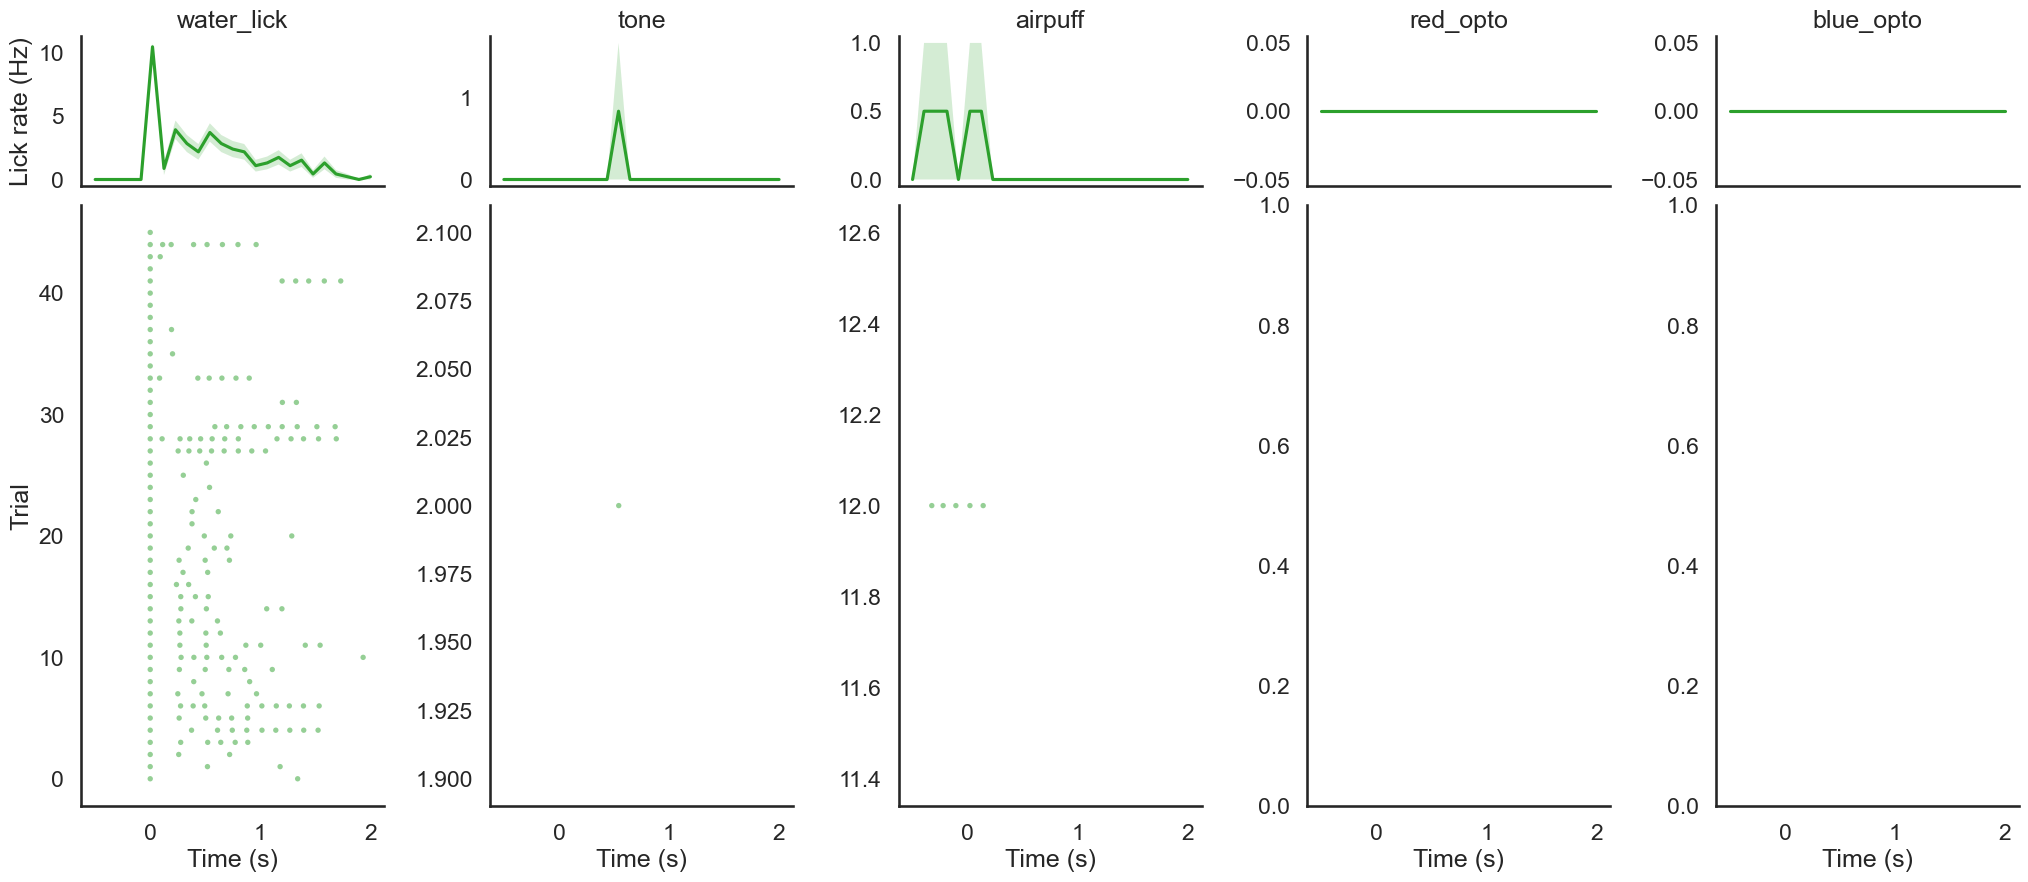

In [ ]:
n_events_plot = len(event_types)
fig = plt.figure(figsize=(5 * n_events_plot, 10))
outer_gs = fig.add_gridspec(1, n_events_plot, wspace=0.35)

for col, (event_times, event_name) in enumerate(zip(event_types, event_names)):
    lick_aligned = ndap.get_licks(lick_onsets, event_times, time_range=(-0.5, 2), bin_size_ms=100)

    inner_gs = outer_gs[col].subgridspec(2, 1, height_ratios=[1, 4], hspace=0.05)
    ax_rate   = fig.add_subplot(inner_gs[0])
    ax_raster = fig.add_subplot(inner_gs[1], sharex=ax_rate)

    ndap.plot_sem(lick_aligned['rate'], lick_aligned['xaxis'],
                    plot_individual=False, color='tab:green', ax=ax_rate)
    ax_rate.set_ylabel('Lick rate (Hz)' if col == 0 else '')
    ax_rate.set_title(event_name)
    ax_rate.tick_params(axis='x', labelbottom=False)
    ax_rate.spines['top'].set_visible(False)
    ax_rate.spines['right'].set_visible(False)

    ndap.plot_raster(lick_aligned['times'], lick_aligned['xaxis'],
                        color='tab:green', ax=ax_raster)
    ax_raster.set_xlabel('Time (s)')
    ax_raster.set_ylabel('Trial' if col == 0 else '')
    ax_raster.spines['top'].set_visible(False)
    ax_raster.spines['right'].set_visible(False)